In [29]:
import netket as nk
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
from netket.operator.spin import sigmax, sigmaz

Here we need to be able to do the following.

1 have a hilbert space: this part is simple as we work with spins its just a string of 0s and 1s, so its a custom sized integer

2 define the graph: this matches the ordering, this is more tricky for more interesting configurations. But the basic idea is a dictionary to the neighbors. So when I say i and i+1 in the operator, I mean the neighbors with larger numbers + PBC logic.
For diagnostic purposes I can also design a visualizer for the graph using graph libraries.

In [30]:

# 2D TFIM on 4x4 square lattice, periodic BCs
L = 4
J = 1.0     # Ising coupling
h = 1.0     # transverse field
n_iter = 300
g = nk.graph.Hypercube(length=L, n_dim=2, pbc=True)   # 4x4 with PBC
hi = nk.hilbert.Spin(s=1/2, N=g.n_nodes)

Now comes the Hamiltonian. We want it to be made up of local operators, netket makes it neatly with implicit kronecker products but we only need it abstractly. So H for us is a ruleset ot evaluate the expectation values of observables on. This goes for any other operator.

In [31]:

# Hamiltonian: H = -J sum_<ij> sz_i sz_j - h sum_i sx_i
H = 0 * sigmaz(hi, 0)
for i, j in g.edges():
    H += -J * (sigmaz(hi, i) @ sigmaz(hi, j))

for i in range(hi.size):
    H += -h * sigmax(hi, i)



This is the actual calculation part

1 We need the neural network, for universality it is smart to parametrize it with alpha, I will look into complex parameters but I think that's unnecerssary for now. The first things will be to implement a base class for the model with jax and the do that for FFNN and CNN

2 The sampler will be a simple local metropolis sampler to start, maybe with exchange considerations, I will take this from somewhere as it is not a focus. Maybe stochastic reconfig for the RBM

3 The state itself will define the run parameters, I need to look into why it is ok to do it statically and not define it based on autocorrelation times or convergence criteria.

In [32]:

model   = nk.models.RBM(alpha=2, param_dtype=float)
sampler = nk.sampler.MetropolisLocal(hi, n_chains_per_rank=256)

vstate = nk.vqs.MCState(
    sampler=sampler,
    model=model,
    n_samples=512,
    n_discard_per_chain=100,
)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def _bits_from_states(states_pmhalf: np.ndarray) -> np.ndarray:
    # states shape: (n_states, N), values typically in {-0.5, +0.5}
    return (states_pmhalf > 0).astype(np.uint8)

def _indices_from_bits(bits01: np.ndarray) -> np.ndarray:
    # index = sum_i bit[i] * 2^i (little-endian site order)
    N = bits01.shape[1]
    powers = (1 << np.arange(N, dtype=np.uint64))
    return (bits01.astype(np.uint64) * powers).sum(axis=1)

def statevector_from_vstate(vstate) -> np.ndarray:
    hi = vstate.hilbert
    states = np.asarray(hi.all_states())              # (2^N, N)
    logpsi = np.asarray(vstate.log_value(states))     # (2^N,)
    psi = np.exp(logpsi)
    # place into deterministic computational-basis order
    bits = _bits_from_states(states)
    idx = _indices_from_bits(bits)
    psi_vec = np.zeros(2 ** hi.size, dtype=np.complex128)
    psi_vec[idx] = psi
    psi_vec /= np.linalg.norm(psi_vec)
    return psi_vec

def reduced_density_matrix(psi_vec: np.ndarray, A_sites: list[int], N: int) -> np.ndarray:
    A = np.array(A_sites, dtype=int)
    B = np.array([i for i in range(N) if i not in set(A_sites)], dtype=int)
    nA, nB = len(A), len(B)
    dimA, dimB = 2**nA, 2**nB

    # reshape psi into tensor with one axis per site, then permute to (A,B), then flatten to matrix M
    psi_tensor = psi_vec.reshape([2]*N)
    perm = np.concatenate([A, B])
    psi_perm = np.transpose(psi_tensor, axes=perm)
    M = psi_perm.reshape(dimA, dimB)
    rhoA = M @ M.conj().T
    rhoA /= np.trace(rhoA)
    return rhoA

def von_neumann_entropy(rho: np.ndarray, eps=1e-15) -> float:
    w = np.linalg.eigvalsh(rho)
    w = np.clip(w.real, eps, 1.0)
    return float(-np.sum(w * np.log(w)))

def renyi_entropy(rho: np.ndarray, alpha: float = 2.0, eps=1e-15) -> float:
    if alpha == 1.0:
        return von_neumann_entropy(rho, eps)
    w = np.linalg.eigvalsh(rho)
    w = np.clip(w.real, eps, 1.0)
    return float(1.0 / (1.0 - alpha) * np.log(np.sum(w**alpha)))

# ---- Collect entropies during optimization ----
A_sites = list(range(8))          # example: first half (8 spins) as subsystem A for 4x4 (N=16)
every = 5                         # compute entropy every k VMC steps (entropy is relatively expensive)

steps, SvN, S2 = [], [], []

def entropy_callback(step: int, log_data: dict, driver) -> bool:
    # compute entropy only every 'every' steps
    if step % every != 0:
        return True

    psi_vec = statevector_from_vstate(driver.state)  # driver.state is the vstate
    rhoA = reduced_density_matrix(psi_vec, A_sites=A_sites, N=driver.state.hilbert.size)

    steps.append(step)
    SvN.append(von_neumann_entropy(rhoA))
    S2.append(renyi_entropy(rhoA, alpha=2.0))

    # optionally also log it into NetKet's logger output
    log_data["SvN"] = SvN[-1]
    log_data["S2"] = S2[-1]

    return True  # continue optimisation

In [34]:

# --- Optimisation (VMC driver) ---
opt = nk.optimizer.Adam(learning_rate=1e-2)
sr  = nk.optimizer.SR(diag_shift=1e-2)

log = nk.logging.RuntimeLog()
# gs  = nk.driver.VMC(H, opt, variational_state=vstate, preconditioner=sr)
#gs.run(n_iter=n_iter, out=log)

gs = nk.driver.VMC(H, opt, variational_state=vstate)  # no preconditioner
gs.run(n_iter=n_iter, out=log, callback=entropy_callback, step_size =1)

  0%|          | 0/300 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['acceptance', 'Energy', 'SvN', 'S2'],)

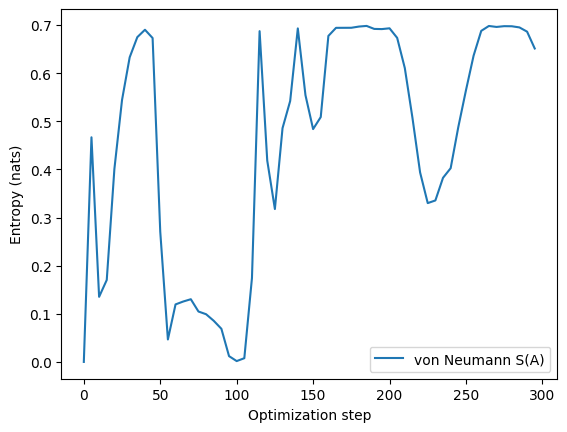

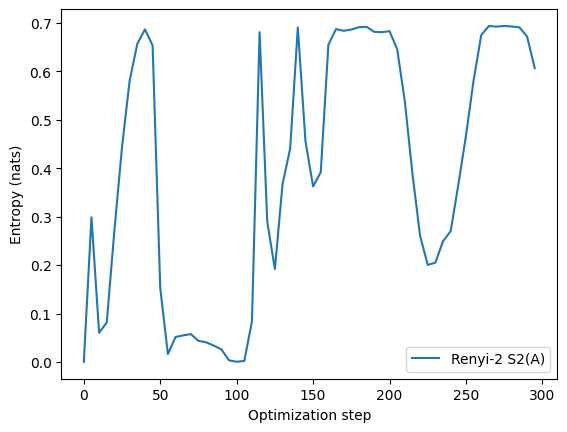

E = -34.01536638608447 +/- 0.025077835091460506


In [35]:

# ---- Plot ----
plt.figure()
plt.plot(steps, SvN, label="von Neumann S(A)")
plt.xlabel("Optimization step")
plt.ylabel("Entropy (nats)")
plt.legend()
plt.show()

plt.figure()
plt.plot(steps, S2, label="Renyi-2 S2(A)")
plt.xlabel("Optimization step")
plt.ylabel("Entropy (nats)")
plt.legend()
plt.show()

# --- Final energy estimate ---
E = vstate.expect(H)
print("E =", float(E.mean), "+/-", float(E.error_of_mean))